In [ ]:
import pandas as pd

customers = pd.read_csv('/content/customers.csv')
orders = pd.read_csv('/content/orders.csv')
payments = pd.read_csv('/content/payments.csv')
items = pd.read_csv('/content/order_items.csv')
products = pd.read_csv('/content/products.csv')
sellers = pd.read_csv('/content/sellers.csv')
geo = pd.read_csv('/content/geolocation.csv')

In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [ ]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
df = orders.merge(customers, on='customer_id', how='left')

df = df.merge(items, on='order_id', how='left')

df = df.merge(products, on='product_id', how='left')

df = df.merge(payments, on='order_id', how='left')

df = df.merge(sellers, on='seller_id', how='left')

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [ ]:
df['revenue'] = (
    df['price'] + df['freight_value']
)

1. Unique customer cities

In [ ]:
customers['customer_city'].unique()

array(['franca', 'sao bernardo do campo', 'sao paulo', ...,
       'monte bonito', 'sao rafael', 'eugenio de castro'], dtype=object)

2. Orders placed in 2017

In [ ]:
orders_2017 = orders[
    orders['order_purchase_timestamp'].dt.year == 2017
]

orders_2017['order_id'].nunique()

45101

3. Total sales per category

In [ ]:
sales_per_category = (
    df.groupby('product category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

sales_per_category

,revenue
product category,
HEALTH BEAUTY,1486023.75
Watches present,1357478.82
bed table bath,1310284.13
sport leisure,1198524.35
computer accessories,1095456.98
...,...
flowers,1598.91
House Comfort 2,1194.44
cds music dvds,954.99


4. Percentage of installment orders

In [ ]:
installment_orders = payments[
    payments['payment_installments'] > 1
]['order_id'].nunique()

total_orders = payments['order_id'].nunique()

percentage = (
    installment_orders / total_orders
) * 100

round(percentage, 2)

51.46

5. Customers from each state

In [ ]:
customers_per_state = (
    customers.groupby('customer_state')['customer_id']
    .nunique()
    .sort_values(ascending=False)
)

customers_per_state

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


1. Orders per month in 2018

In [ ]:
orders['year'] = (
    orders['order_purchase_timestamp'].dt.year
)

orders['month'] = (
    orders['order_purchase_timestamp'].dt.month
)

monthly_orders = (
    orders[orders['year'] == 2018]
    .groupby('month')['order_id']
    .nunique()
)

monthly_orders

,order_id
month,
1,7269
2,6728
3,7211
4,6939
5,6873
6,6167
7,6292
8,6512
9,16


2. Average products per order by city

In [ ]:
products_per_order = (
    df.groupby('order_id')['order_item_id']
    .count()
    .reset_index(name='product_count')
)

products_per_order = products_per_order.merge(
    orders[['order_id', 'customer_id']],
    on='order_id'
)

products_per_order = products_per_order.merge(
    customers[['customer_id', 'customer_city']],
    on='customer_id'
)

avg_products_city = (
    products_per_order.groupby('customer_city')
    ['product_count']
    .mean()
    .sort_values(ascending=False)
)

avg_products_city

,product_count
customer_city,
padre carvalho,7.0
celso ramos,6.5
candido godoi,6.0
datas,6.0
matias olimpio,5.0
...,...
jataizinho,0.0
doutor mauricio cardoso,0.0
monteiro lobato,0.0


3. Revenue contribution percentage by category

In [ ]:
category_revenue = (
    df.groupby('product category')['revenue']
    .sum()
)

total_revenue = category_revenue.sum()

revenue_percentage = (
    category_revenue / total_revenue
) * 100

revenue_percentage.sort_values(ascending=False)

,revenue
product category,
HEALTH BEAUTY,9.091548
Watches present,8.305106
bed table bath,8.016367
sport leisure,7.332616
computer accessories,6.702046
...,...
flowers,0.009782
House Comfort 2,0.007308
cds music dvds,0.005843


4. Correlation between price and purchase frequency

In [ ]:
purchase_freq = (
    df.groupby('product_id')
    .agg({
        'price': 'mean',
        'order_id': 'count'
    })
    .rename(columns={
        'order_id': 'purchase_count'
    })
)

correlation = (
    purchase_freq['price']
    .corr(purchase_freq['purchase_count'])
)

correlation

np.float64(-0.032149460705646865)

5. Seller revenue ranking

In [ ]:
seller_revenue = (
    df.groupby('seller_id')['revenue']
    .sum()
    .reset_index()
)

seller_revenue['rank'] = (
    seller_revenue['revenue']
    .rank(method='dense', ascending=False)
)

seller_revenue.sort_values('rank')

,seller_id,revenue,rank
1013,53243585a1d6dc2643021fd1853d8905,258882.28,1.0
857,4869f7a5dfa277a7dca6462dcf3b52b2,258625.52,2.0
1535,7c67e1448b00f6e969d365cea6b010ab,252549.32,3.0
881,4a3ca9315b744ce9f8e9374361493884,250635.29,4.0
3024,fa1c13f2614d7b5c4749cbc52fecda94,214454.82,5.0
...,...,...,...
1370,702835e4b785b67a084280efca355756,18.56,3077.0
869,4965a7002cca77301c82d3f91b82e1a9,16.36,3078.0
373,1fa2d3def6adfa70e58c276bb64fe5bb,15.90,3079.0
1465,77128dec4bec4878c37ab7d6169d6f26,15.22,3080.0


1. Moving average of customer order values

In [ ]:
order_value = (
    df.groupby([
        'customer_id',
        'order_id',
        'order_purchase_timestamp'
    ])['revenue']
    .sum()
    .reset_index()
)

order_value = order_value.sort_values(
    by=['customer_id', 'order_purchase_timestamp']
)

order_value['moving_avg'] = (
    order_value.groupby('customer_id')['revenue']
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

order_value

,customer_id,order_id,order_purchase_timestamp,revenue,moving_avg
0,00012a2ce6f8dcda20d059ce98491703,5f79b5b0931d63f1a42989eb65b9da6e,2017-11-14 16:08:26,114.74,114.74
1,000161a058600d5901f007fab4c27140,a44895d095d7e0702b6a162fa2dbeced,2017-07-16 9:40:32,67.41,67.41
2,0001fd6190edaaf884bcaf3d49edf079,316a104623542e4d75189bb372bc5f8d,2017-02-28 11:06:43,195.42,195.42
3,0002414f95344307404f0ace7a26f1d5,5825ce2e88d5346438686b0bba99e5ee,2017-08-16 13:09:20,179.35,179.35
4,000379cdec625522490c315e70c7a9fb,0ab7fb08086d4af9141453c91878ed7a,2018-04-02 13:42:17,107.01,107.01
...,...,...,...,...,...
99436,fffecc9f79fd8c764f843e9951b11341,814d6a3a7c0b32b2ad929ac6328124e9,2018-03-29 16:59:26,244.08,244.08
99437,fffeda5b6d849fbd39689bb92087f431,8c855550908247a7eff50281b92167a8,2018-05-22 13:36:02,63.13,63.13
99438,ffff42319e9b2d713724ae527742af25,83b5fc912b2862c5046555ded1483ae9,2018-06-13 16:57:05,214.13,214.13
99439,ffffa3172527f765de70084a7e53aae8,d0e7be325a1c986babc4e1cdb91edc03,2017-09-02 11:53:32,45.50,45.50


In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

2. Cumulative monthly sales

In [ ]:
df['year'] = (
    df['order_purchase_timestamp'].dt.year
)

df['month'] = (
    df['order_purchase_timestamp'].dt.month
)

monthly_sales = (
    df.groupby(['year', 'month'])['revenue']
    .sum()
    .reset_index()
)

monthly_sales['cumulative_sales'] = (
    monthly_sales.groupby('year')['revenue']
    .cumsum()
)

monthly_sales

,year,month,revenue,cumulative_sales
0,2016,9,354.75,354.75
1,2016,10,58550.03,58904.78
2,2016,12,19.62,58924.40
3,2017,1,146455.54,146455.54
4,2017,2,302230.37,448685.91
5,2017,3,457782.29,906468.20
6,2017,4,448742.78,1355210.98
7,2017,5,630089.88,1985300.86
8,2017,6,526495.91,2511796.77
9,2017,7,627312.81,3139109.58


3. Year-over-Year growth

In [ ]:
yearly_sales = (
    df.groupby('year')['revenue']
    .sum()
    .reset_index()
)

yearly_sales['YoY_growth_%'] = (
    yearly_sales['revenue']
    .pct_change()
) * 100

yearly_sales

,year,revenue,YoY_growth_%
0,2016,58924.40,NaN
1,2017,7524684.58,12670.065677
2,2018,8983078.33,19.381460


4. Customer retention within 6 months

In [ ]:
first_purchase = (
    orders.groupby('customer_id')
    ['order_purchase_timestamp']
    .min()
    .reset_index(name='first_purchase')
)

retention_df = orders.merge(
    first_purchase,
    on='customer_id'
)

retention_df['days_diff'] = (
    retention_df['order_purchase_timestamp']
    - retention_df['first_purchase']
).dt.days

retained_customers = retention_df[
    (retention_df['days_diff'] > 0) &
    (retention_df['days_diff'] <= 180)
]['customer_id'].nunique()

total_customers = (
    first_purchase['customer_id']
    .nunique()
)

retention_rate = (
    retained_customers / total_customers
) * 100

round(retention_rate, 2)

0.0

5. Top 3 customers by spending each year

In [ ]:
customer_spending = (
    df.groupby([
        'year',
        'customer_id'
    ])['revenue']
    .sum()
    .reset_index()
)

customer_spending['rank'] = (
    customer_spending.groupby('year')['revenue']
    .rank(method='dense', ascending=False)
)

top_3_customers = (
    customer_spending[
        customer_spending['rank'] <= 3
    ]
)

top_3_customers

,year,customer_id,revenue,rank
38,2016,1d34ed25963d5aae4cf3d7f3a4cda173,1400.74,2.0
84,2016,4a06381959b6670756de02e07b83815f,1227.78,3.0
223,2016,a9dc96b027d1252bbac0a9b72d837fc6,1423.55,1.0
4218,2017,1617b1357756262bfa56ab541c47bc16,13664.08,1.0
27645,2017,9af2372a1e49340278e7c1ef8d749f34,13281.71,2.0
39604,2017,de832e8dbb1f588a47013e53feaa67cc,11111.40,3.0
66449,2018,63b964e79dee32a3587651701a2b8dbf,10553.28,1.0
68829,2018,6f241d5bbb142b6f764387c8c270645a,10055.22,2.0
95169,2018,eb7a157e8da9c488cd4ddc48711f1097,8068.88,3.0


------------------------------------------


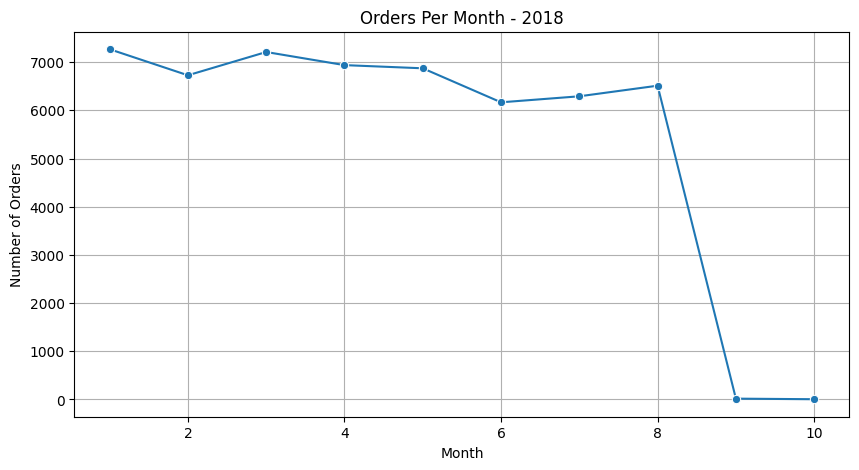

In [ ]:
monthly_orders = (
    orders[orders['year'] == 2018]
    .groupby('month')['order_id']
    .nunique()
    .reset_index()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_orders,
    x='month',
    y='order_id',
    marker='o'
)

plt.title('Orders Per Month - 2018')

plt.xlabel('Month')

plt.ylabel('Number of Orders')

plt.grid(True)

plt.show()

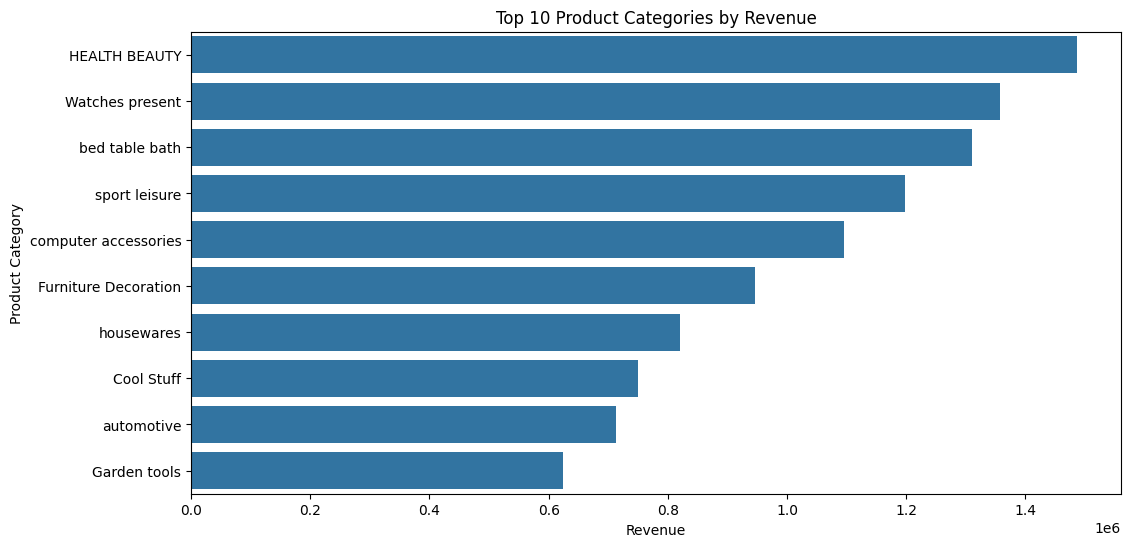

In [ ]:
top_categories = (
    df.groupby('product category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories,
    x='revenue',
    y='product category'
)

plt.title('Top 10 Product Categories by Revenue')

plt.xlabel('Revenue')

plt.ylabel('Product Category')

plt.show()

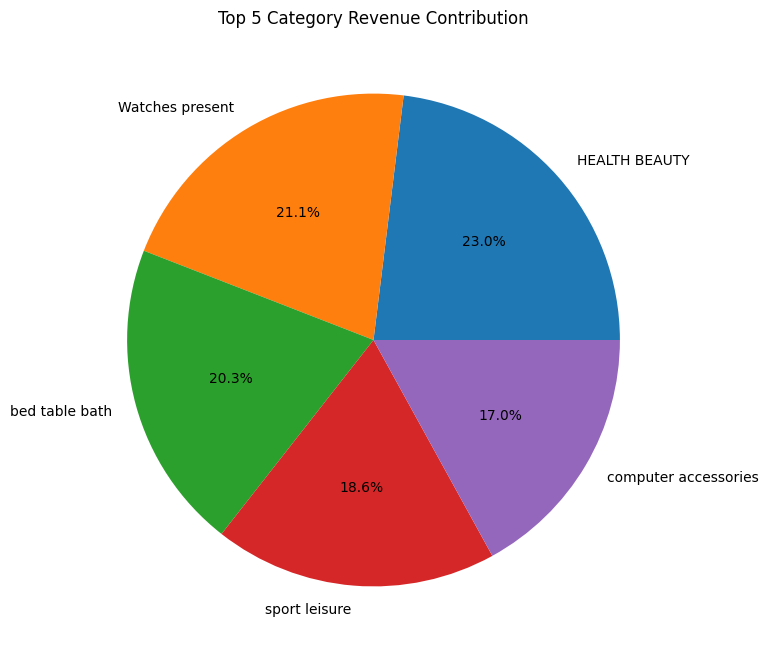

In [ ]:
category_revenue = (
    df.groupby('product category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,8))

plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct='%1.1f%%'
)

plt.title('Top 5 Category Revenue Contribution')

plt.show()

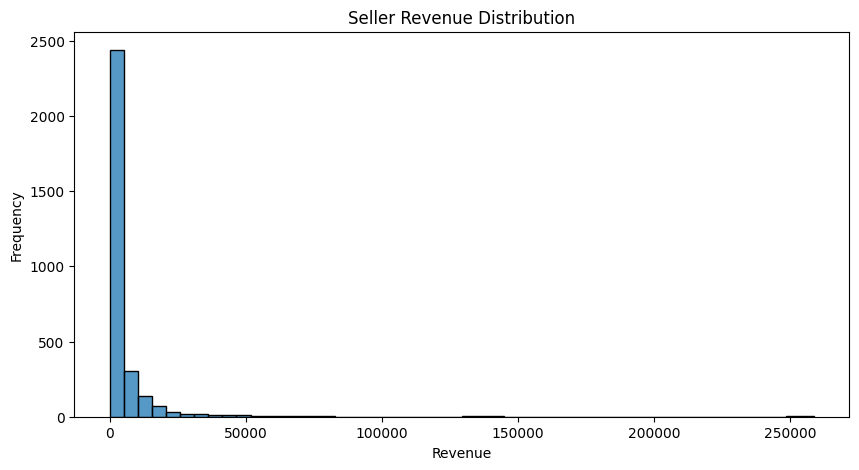

In [ ]:
seller_revenue = (
    df.groupby('seller_id')['revenue']
    .sum()
)

plt.figure(figsize=(10,5))

sns.histplot(
    seller_revenue,
    bins=50
)

plt.title('Seller Revenue Distribution')

plt.xlabel('Revenue')

plt.ylabel('Frequency')

plt.show()

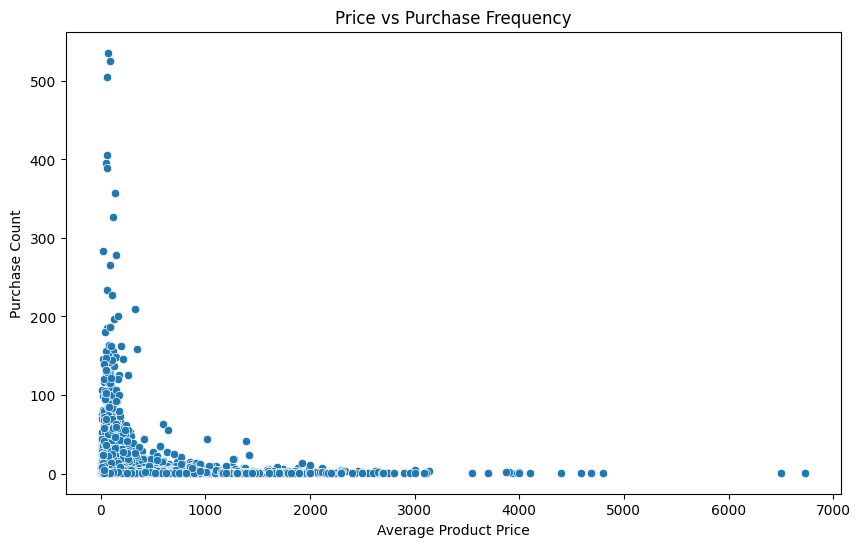

In [ ]:
purchase_freq = (
    df.groupby('product_id')
    .agg({
        'price': 'mean',
        'order_id': 'count'
    })
    .rename(columns={
        'order_id': 'purchase_count'
    })
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=purchase_freq,
    x='price',
    y='purchase_count'
)

plt.title('Price vs Purchase Frequency')

plt.xlabel('Average Product Price')

plt.ylabel('Purchase Count')

plt.show()

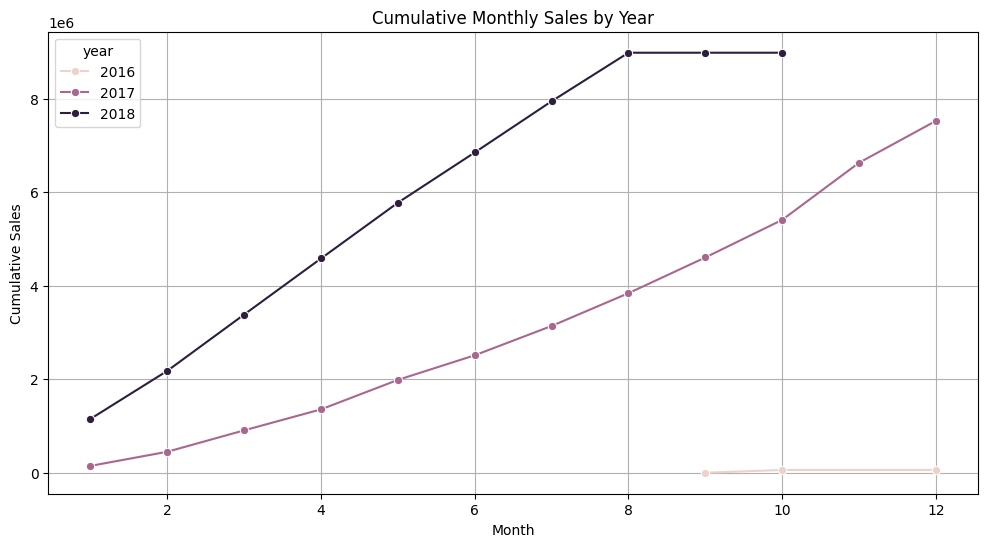

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='cumulative_sales',
    hue='year',
    marker='o'
)

plt.title('Cumulative Monthly Sales by Year')

plt.xlabel('Month')

plt.ylabel('Cumulative Sales')

plt.grid(True)

plt.show()

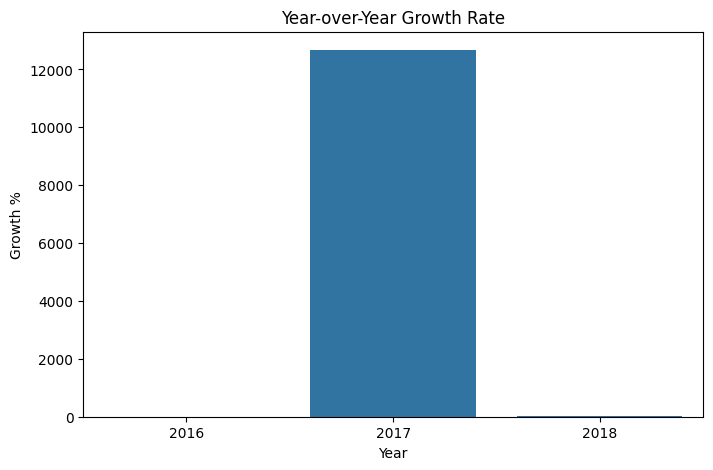

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_sales,
    x='year',
    y='YoY_growth_%'
)

plt.title('Year-over-Year Growth Rate')

plt.xlabel('Year')

plt.ylabel('Growth %')

plt.show()

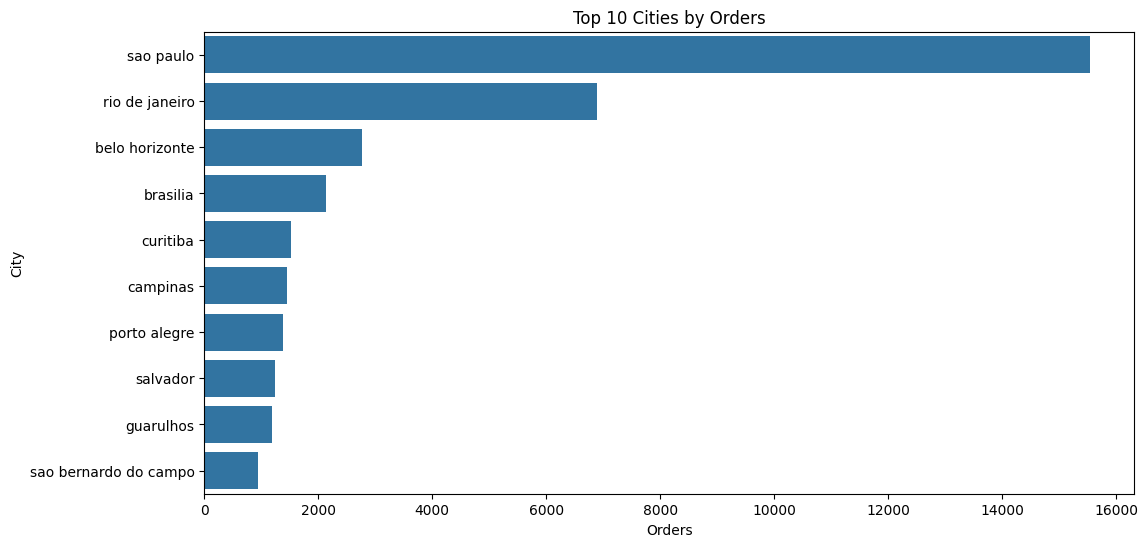

In [ ]:
top_cities = (
    df.groupby('customer_city')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cities,
    x='order_id',
    y='customer_city'
)

plt.title('Top 10 Cities by Orders')

plt.xlabel('Orders')

plt.ylabel('City')

plt.show()

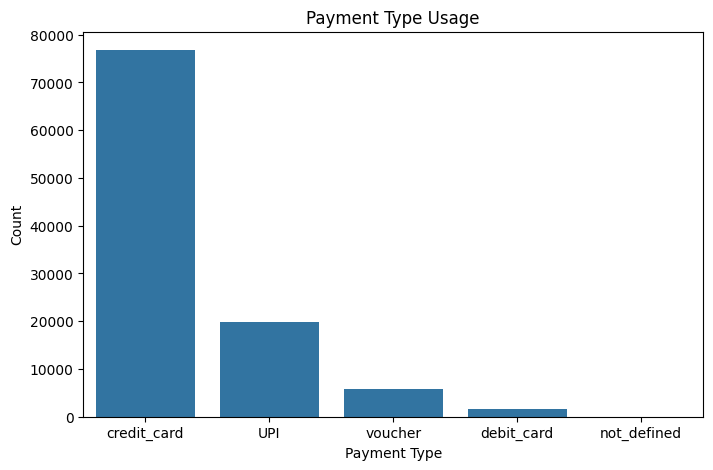

In [ ]:
payment_counts = (
    payments['payment_type']
    .value_counts()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title('Payment Type Usage')

plt.xlabel('Payment Type')

plt.ylabel('Count')

plt.show()

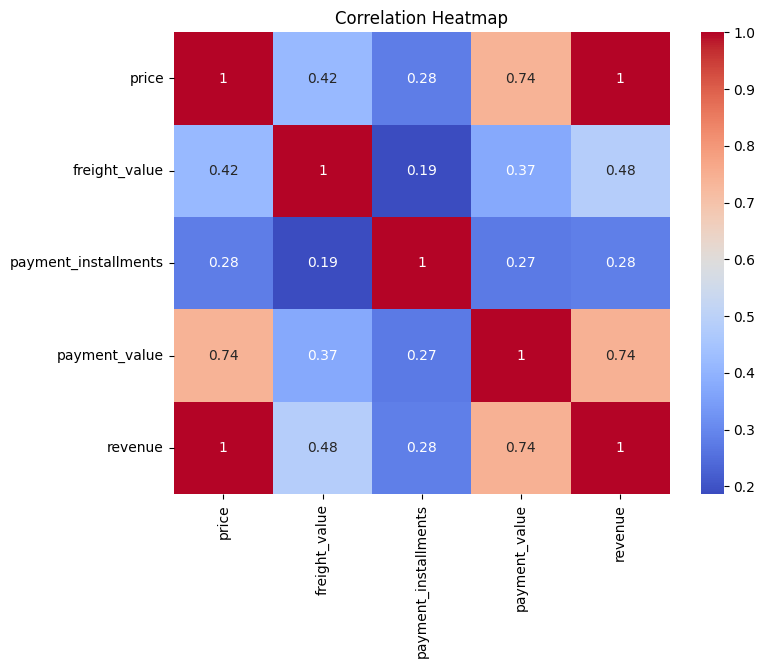

In [ ]:
corr_df = df[[
    'price',
    'freight_value',
    'payment_installments',
    'payment_value',
    'revenue'
]]

correlation_matrix = corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()